<a href="https://colab.research.google.com/github/shafiqul-cyber/Skill_Morph_Practice_from_Instrictor-/blob/Skill_Morph/Assignment_8_Stroke_Detection_Using_Multiple_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stroke Detection Detection**

## **Font family setup**

In [ ]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data?select=healthcare-dataset-stroke-data.csv

## **Importing Dataset**

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/skill_morph/healthcare_dataset_stroke_data.csv")

## **Basic Information**

In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.shape

(5110, 12)

In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


## **Data Samples per Class**

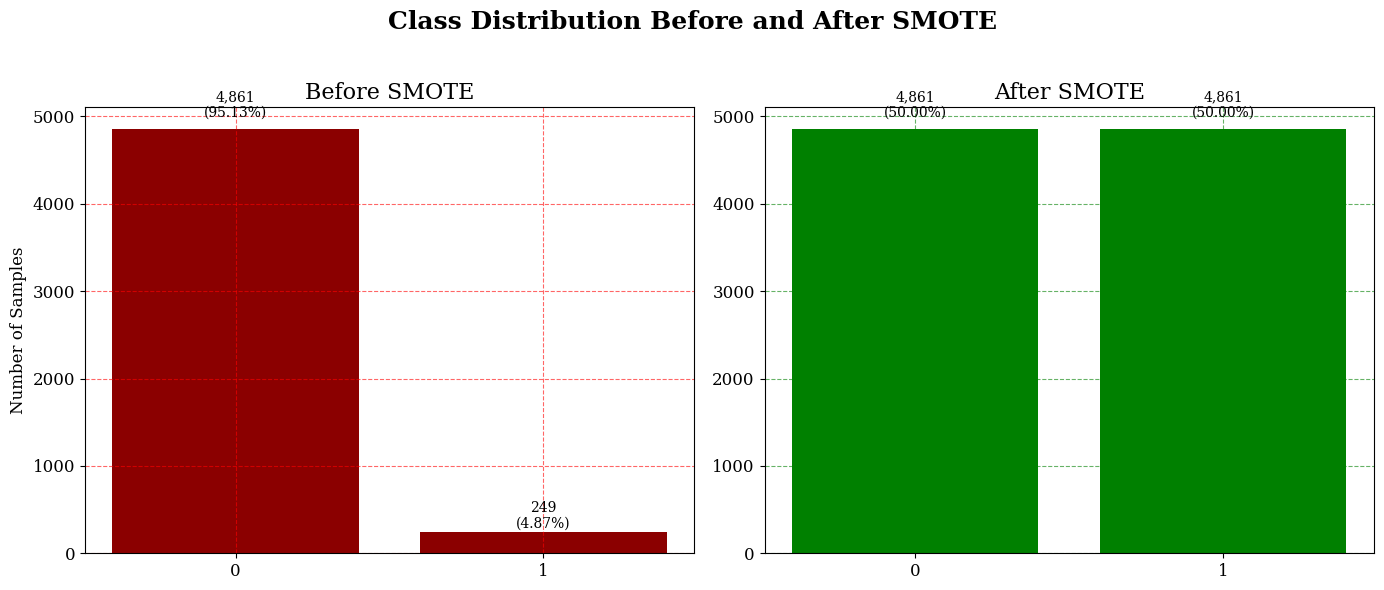

✅ Before SMOTE:
 stroke
0    4861
1     249
Name: count, dtype: int64

✅ After SMOTE:
 stroke
0    4861
1    4861
Name: count, dtype: int64

📁 Plot saved successfully to: /content/drive/MyDrive/skill_morph/smote_balance_2025-10-14_10-50-50/smote_before_after_balance.png


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import os
from datetime import datetime

# ============================================================
# 1️⃣ Apply SMOTE
# ============================================================
# Assuming X and y are already defined and preprocessed
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# ============================================================
# 2️⃣ Prepare Before and After Data
# ============================================================
y_before = pd.Series(y, name='stroke')              # Original
y_after = pd.Series(y_resampled, name='stroke')     # After SMOTE

count_before = y_before.value_counts().sort_index()
count_after = y_after.value_counts().sort_index()
perc_before = (count_before / count_before.sum()) * 100
perc_after = (count_after / count_after.sum()) * 100

# ============================================================
# 3️⃣ Create Output Folder in Google Drive
# ============================================================
base_path = "/content/drive/MyDrive/skill_morph"
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_path = os.path.join(base_path, f"smote_balance_{timestamp}")
os.makedirs(save_path, exist_ok=True)

# ============================================================
# 4️⃣ Plot Before vs After SMOTE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Distribution Before and After SMOTE", fontsize=18, fontweight='bold')

# ---------- BEFORE SMOTE ----------
bars1 = axes[0].bar(count_before.index.astype(str), count_before.values, color='darkred')
axes[0].set_title("Before SMOTE", fontsize=16)
axes[0].set_ylabel("Number of Samples", fontsize=12)
axes[0].grid(axis='both', linestyle='--', alpha=0.6, color='red')

for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_before.values[i]:,}\n({perc_before.values[i]:.2f}%)',
        ha='center', va='bottom', fontsize=10
    )

# ---------- AFTER SMOTE ----------
bars2 = axes[1].bar(count_after.index.astype(str), count_after.values, color='green')
axes[1].set_title("After SMOTE", fontsize=16)
axes[1].grid(axis='both', linestyle='--', alpha=0.6, color='green')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_after.values[i]:,}\n({perc_after.values[i]:.2f}%)',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ============================================================
# 5️⃣ Save Plot to Google Drive
# ============================================================
plot_path = os.path.join(save_path, "smote_before_after_balance.png")
plt.savefig(plot_path, dpi=300)
plt.show()

# ============================================================
# 6️⃣ Print Confirmation and Counts
# ============================================================
print("✅ Before SMOTE:\n", count_before)
print("\n✅ After SMOTE:\n", count_after)
print(f"\n📁 Plot saved successfully to: {plot_path}")


## **Handle Missing Values**

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled

Columns with Missing Values:
 bmi    201
dtype: int64
Missing values after filling:
 0


In [ ]:
# Print the names of the features (columns)
print(df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


## **Data Preprocessing**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Replace infinite and invalid values
df = df.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

# Separate features and target
target_col = 'stroke'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)   # Ensure target is integer

# Separate numerical and categorical columns (from X only)
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Normalize numerical columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Encode categorical columns (loop ensures each col uses its own encoder)
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("✅ Preprocessing complete.")
X.head(), y.head()

# Combine features and target into one DataFrame
df_processed = X.copy()
df_processed['stroke'] = y

# Save to CSV
df_processed.to_csv("/content/drive/MyDrive/skill_morph/healthcare_processed.csv", index=False)

print("✅ Preprocessed dataset saved successfully at:")
print("/content/drive/MyDrive/skill_morph/healthcare_processed.csv")


✅ Preprocessing complete.
✅ Preprocessed dataset saved successfully at:
/content/drive/MyDrive/skill_morph/healthcare_processed.csv


✅ Before SMOTE:
stroke
0    4861
1     249
Name: count, dtype: int64

✅ After SMOTE:
stroke
1    4861
0    4861
Name: count, dtype: int64


In [ ]:
# I have no additional column name unnamed, i it occurs then remove using below code
#df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df_processed.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,-1.298312,1,1.051434,-0.328602,4.185032,1,2,1,2.706375,1.005086,1,1
1,0.716371,0,0.786070,-0.328602,-0.238947,1,3,0,2.121559,-0.098981,2,1
2,-0.255478,1,1.626390,-0.328602,4.185032,1,2,0,-0.005028,0.472536,2,1
3,1.118363,0,0.255342,-0.328602,-0.238947,1,2,1,1.437358,0.719327,3,1
4,-1.647136,0,1.582163,3.043196,-0.238947,1,3,0,1.501184,-0.631531,2,1


## **After Processing**

In [ ]:
df_processed['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
#### Copy the processed df to different DataFrames
df1 = df_processed.copy()
df2 = df_processed.copy()

print("✅ Copies created successfully.")


✅ Copies created successfully.


# **Binary Class (Anomaly) Classification**

In [ ]:
#If the Label column has a multiclass then it below line convert it binary class or two class only
#df1['Label'] = df1['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Ransomware')

In [ ]:
# Check counts
print(df1['stroke'].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


In [ ]:
# Define label and feature columns
X = df1.drop(columns=['stroke'])
y = df1['stroke']

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to balance the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print("✅ Before SMOTE:")
print(y.value_counts())
print("\n✅ After SMOTE:")
print(y_resampled.value_counts())


✅ Before SMOTE:
stroke
0    4861
1     249
Name: count, dtype: int64

✅ After SMOTE:
stroke
1    4861
0    4861
Name: count, dtype: int64


In [ ]:
print("✅ Class distribution after SMOTE:\n", y_resampled.value_counts())


✅ Class distribution after SMOTE:
 stroke
1    4861
0    4861
Name: count, dtype: int64


## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split the balanced dataset (from SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,     # ✅ use balanced data
    test_size=0.2,                # 30% test, 70% train
    random_state=42,
    stratify=y_resampled          # keep balance ratio
)

# Confirm new sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (7777, 11)
X_test shape:  (1945, 11)
y_train shape: (7777,)
y_test shape:  (1945,)


## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.8889
Precision: 0.8893
Recall:    0.8889
F1 Score:  0.8889


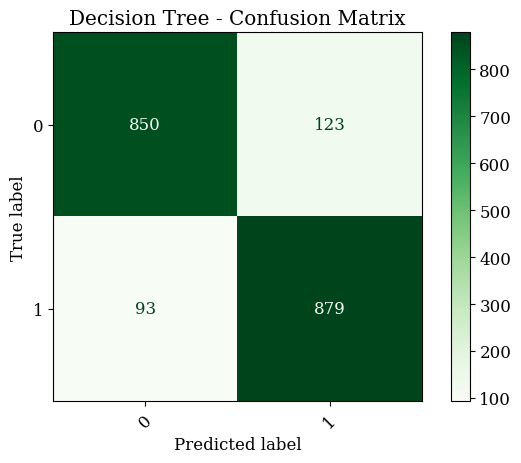

Classification Report:
              precision    recall  f1-score   support

           0    0.90138   0.87359   0.88727       973
           1    0.87725   0.90432   0.89058       972

    accuracy                        0.88895      1945
   macro avg    0.88931   0.88895   0.88892      1945
weighted avg    0.88932   0.88895   0.88892      1945



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Without Cross Validation**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, fbeta_score, brier_score_loss, log_loss,
    classification_report, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =====================================================
# 0️⃣ CREATE TIMESTAMPED MASTER RESULTS FOLDER
# =====================================================
base_path = "/content/drive/MyDrive/skill_morph/Results_14_10_2025"
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
main_path = os.path.join(base_path, f"results_{timestamp}")
os.makedirs(main_path, exist_ok=True)

# Create subfolders
folders = {
    "csv": os.path.join(main_path, "csv_metrics"),
    "roc": os.path.join(main_path, "roc_curves"),
    "confusion": os.path.join(main_path, "confusion_matrices"),
    "prc": os.path.join(main_path, "precision_recall_curves"),
    "training": os.path.join(main_path, "training_accuracy_curves"),
    "reports": os.path.join(main_path, "classification_reports"),
}
for path in folders.values():
    os.makedirs(path, exist_ok=True)

print(f"📁 All results will be organized in:\n{main_path}\n")

# =====================================================
# 1️⃣ DEFINE MODELS
# =====================================================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

results, roc_curves = [], []

# =====================================================
# 2️⃣ TRAIN, EVALUATE, COLLECT METRICS
# =====================================================
for name, model in models.items():
    print(f"🚀 Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_prob = model.decision_function(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Specificity": specificity,
        "Sensitivity": sensitivity,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_test, y_pred),
        "F2-Score": fbeta_score(y_test, y_pred, beta=2, average='weighted', zero_division=0),
        "Brier Score": brier_score_loss(y_test, y_prob),
        "Log Loss": log_loss(y_test, y_prob)
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves.append((name, fpr, tpr, roc_auc_score(y_test, y_prob)))

# =====================================================
# 3️⃣ SAVE METRICS TABLE
# =====================================================
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
csv_path = os.path.join(folders["csv"], "model_results_full_metrics.csv")
results_df.to_csv(csv_path, index=False)
print(f"✅ Metrics CSV saved: {csv_path}")

# =====================================================
# 4️⃣ ROC CURVES (COMBINED + INDIVIDUAL)
# =====================================================
roc_curves_sorted = sorted(roc_curves, key=lambda x: x[3], reverse=True)

plt.figure(figsize=(8, 6))
for name, fpr, tpr, auc in roc_curves_sorted:
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curves for All Models (Sorted by AUC)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(folders["roc"], "combined_ROC.png"), dpi=300)
plt.close()

# Individual ROC
for name, fpr, tpr, auc in roc_curves_sorted:
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc:.3f}')
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(folders["roc"], f"{name.replace(' ', '_')}_ROC.png"), dpi=300)
    plt.close()
print("✅ ROC curves saved.\n")

# =====================================================
# 5️⃣ CONFUSION MATRICES (INDIVIDUAL)
# =====================================================
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Greens', colorbar=True)
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(folders["confusion"], f"{name.replace(' ', '_')}_confusion_matrix.png"), dpi=300)
    plt.close()
print("✅ Confusion matrices saved.\n")

# =====================================================
# 6️⃣ PRECISION–RECALL CURVES (INDIVIDUAL)
# =====================================================
for name, model in models.items():
    print(f"Generating Precision–Recall for {name}")
    model.fit(X_train, y_train)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_prob = model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot(color='blue', lw=2)
    plt.title(f'Precision–Recall Curve ({name})')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(folders["prc"], f"{name.replace(' ', '_')}_PRC.png"), dpi=300)
    plt.close()
print("✅ Precision–Recall curves saved.\n")

# =====================================================
# 7️⃣ TRAINING ACCURACY VS NUMBER OF ESTIMATORS (ENSEMBLE MODELS)
# =====================================================
ensemble_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}
n_estimators = np.arange(1, 110, 10)

for name, model in ensemble_models.items():
    train_acc, test_acc = [], []
    for n in n_estimators:
        model.set_params(n_estimators=n)
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    plt.figure(figsize=(7,5))
    plt.plot(n_estimators, train_acc, 'ro-', label='Training Accuracy')
    plt.plot(n_estimators, test_acc, 'go-', label='Test Accuracy')
    plt.title(f'Accuracy vs Number of Estimators ({name})')
    plt.xlabel('Number of Estimators (Trees)')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(folders["training"], f"{name.replace(' ', '_')}_accuracy_vs_estimators.png"), dpi=300)
    plt.close()
print("✅ Training vs Testing accuracy curves saved.\n")

# =====================================================
# 8️⃣ BEST MODEL REPORT
# =====================================================
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
report_text = classification_report(y_test, best_model.predict(X_test), digits=5)
report_path = os.path.join(folders["reports"], f"{best_model_name.replace(' ', '_')}_classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"Best Model: {best_model_name}\n\n")
    f.write(report_text)
print(f"🏆 Best Model: {best_model_name}")
print(report_text)
print(f"✅ Classification report saved: {report_path}")

# =====================================================
# 9️⃣ SUMMARY
# =====================================================
print("\n🎯 All results saved and organized successfully!")
for key, path in folders.items():
    print(f"📂 {key.capitalize()} Folder: {path}")


📁 All results will be organized in:
/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42

🚀 Training: Decision Tree
🚀 Training: Random Forest
🚀 Training: Extra Trees
🚀 Training: Gradient Boosting
🚀 Training: AdaBoost
🚀 Training: Bagging
🚀 Training: Logistic Regression
🚀 Training: KNN
🚀 Training: SVM
🚀 Training: Naive Bayes
🚀 Training: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:43:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🚀 Training: LightGBM
[LightGBM] [Info] Number of positive: 3889, number of negative: 3888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 7777, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500064 -> initscore=0.000257
[LightGBM] [Info] Start training from score 0.000257
✅ Metrics CSV saved: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/csv_metrics/model_results_full_metrics.csv
✅ ROC curves saved.

✅ Confusion matrices saved.

Generating Precision–Recall for Decision Tree
Generating Precision–Recall for Random Forest
Generating Precision–Recall for Extra Trees
Generating Precision–Recall for Gradient Boosting
Generating Precision–Recall for AdaBoost
Gen

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:44:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Generating Precision–Recall for LightGBM
[LightGBM] [Info] Number of positive: 3889, number of negative: 3888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 7777, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500064 -> initscore=0.000257
[LightGBM] [Info] Start training from score 0.000257
✅ Precision–Recall curves saved.

✅ Training vs Testing accuracy curves saved.

🏆 Best Model: Extra Trees
              precision    recall  f1-score   support

           0    0.97168   0.91675   0.94342       973
           1    0.92113   0.97325   0.94647       972

    accuracy                        0.94499      1945
   macro avg    0.94640   0.94500   0.94494      1945
weighted avg    0.94642   0.

In [24]:
# Access the file in Google Drive
result1 = pd.read_csv("/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/csv_metrics/model_results_full_metrics.csv")
print(result1)

                  Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0           Extra Trees  0.944987   0.946417  0.944987  0.944944  0.991692   
1              LightGBM  0.944987   0.945010  0.944987  0.944986  0.990158   
2         Random Forest  0.938303   0.939124  0.938303  0.938275  0.989579   
3               XGBoost  0.936247   0.936610  0.936247  0.936234  0.987732   
4               Bagging  0.926992   0.927212  0.926992  0.926983  0.975478   
5                   KNN  0.894087   0.908075  0.894087  0.893178  0.952557   
6     Gradient Boosting  0.852956   0.854595  0.852956  0.852789  0.937216   
7                   SVM  0.838560   0.841236  0.838560  0.838248  0.913689   
8         Decision Tree  0.888946   0.889318  0.888946  0.888920  0.888954   
9              AdaBoost  0.791774   0.795227  0.791774  0.791171  0.888359   
10  Logistic Regression  0.794344   0.794752  0.794344  0.794276  0.868485   
11          Naive Bayes  0.749100   0.749249  0.749100  0.749060


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/confusion_matrices


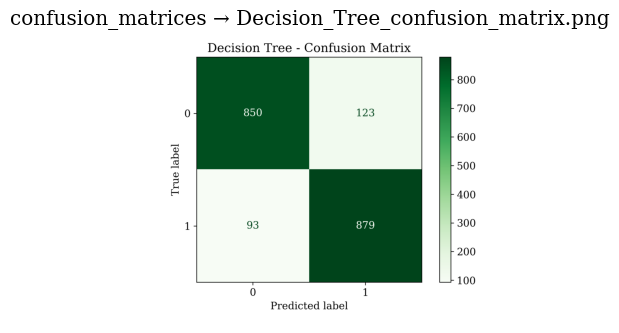

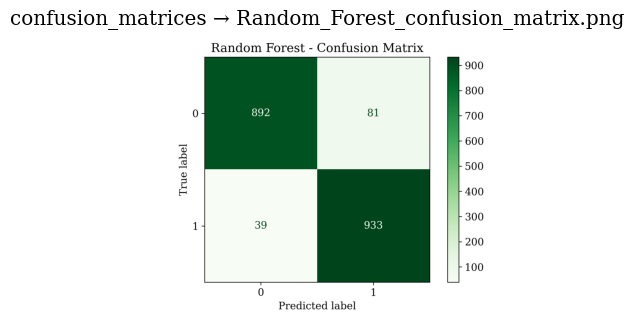

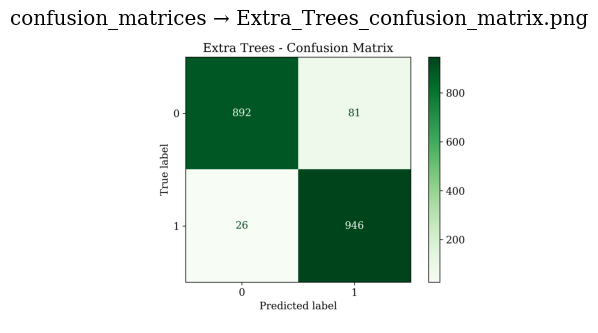

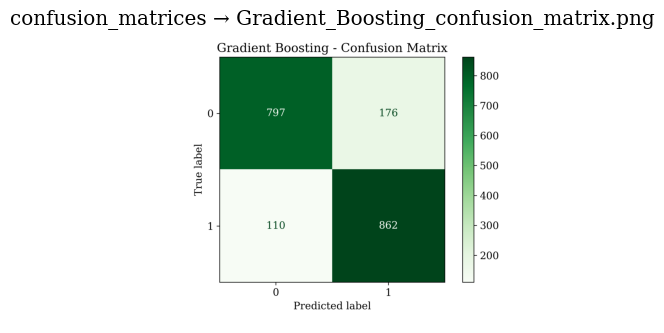

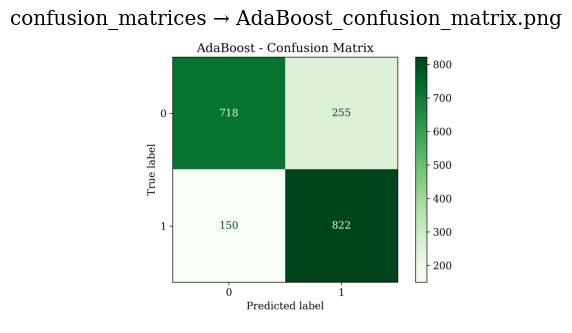

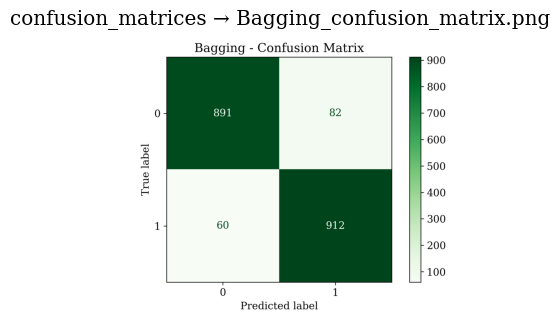

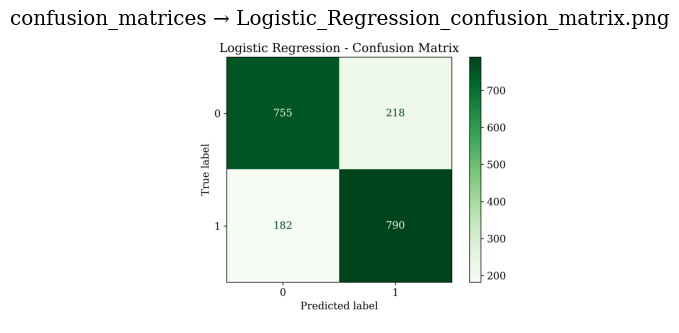

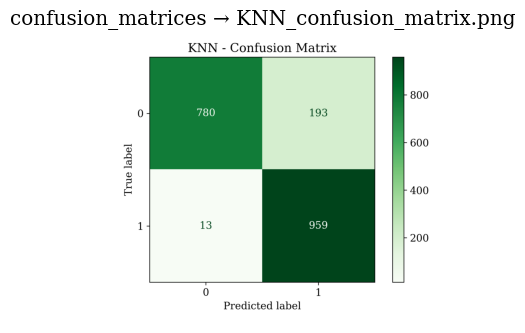

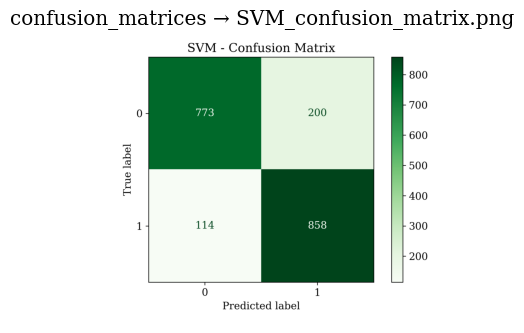

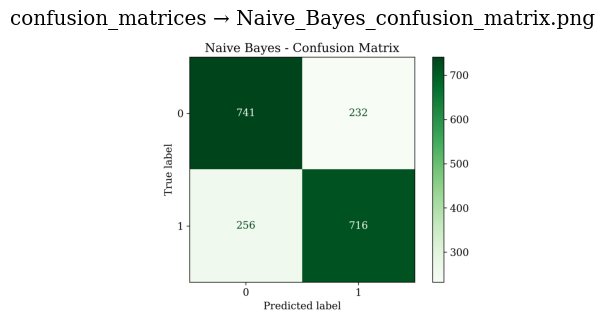

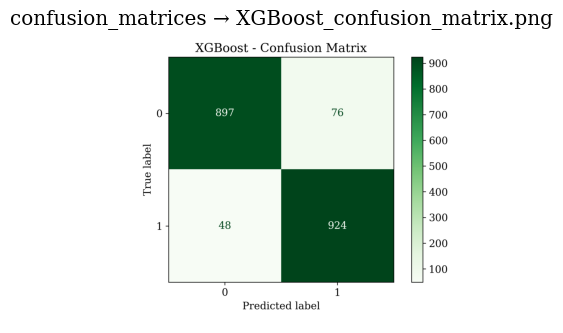

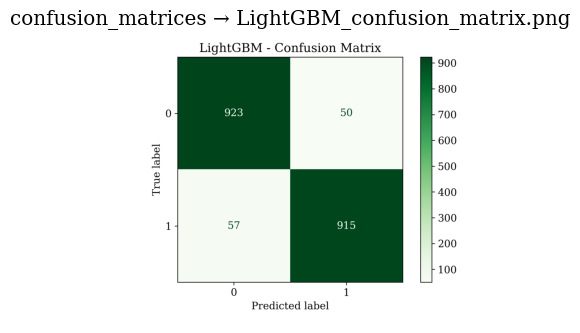


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/precision_recall_curves


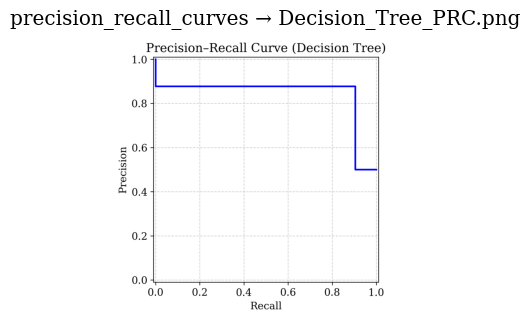

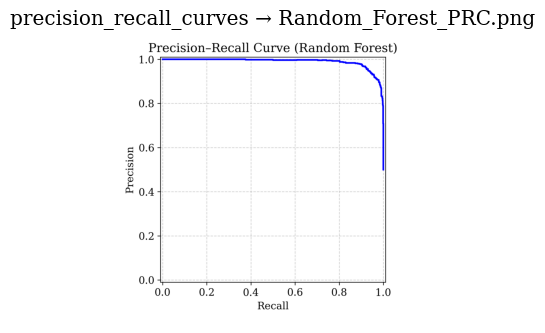

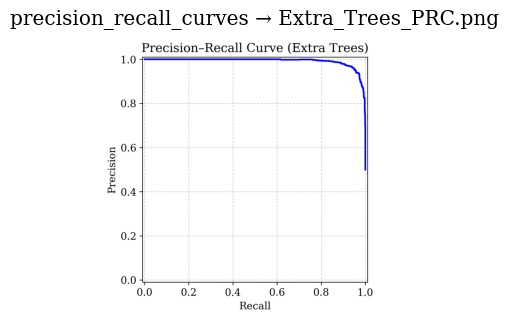

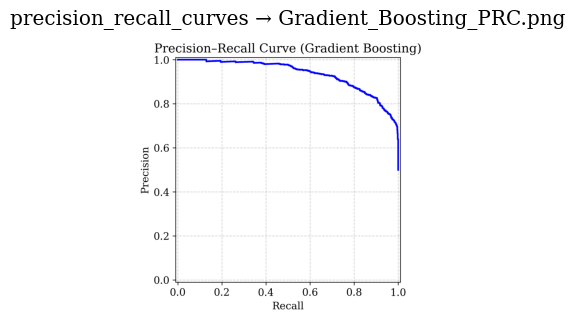

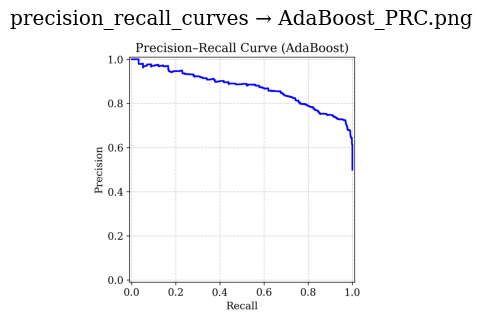

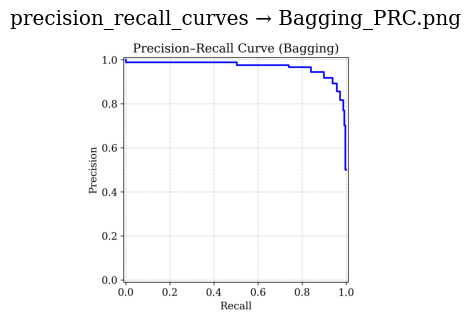

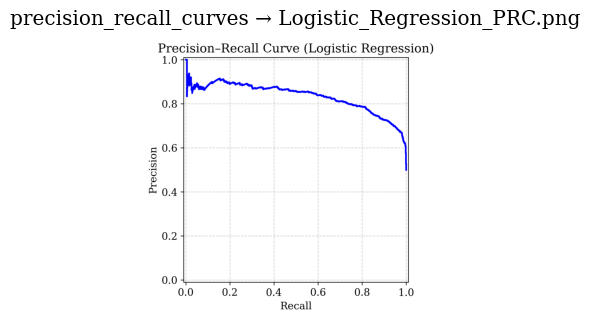

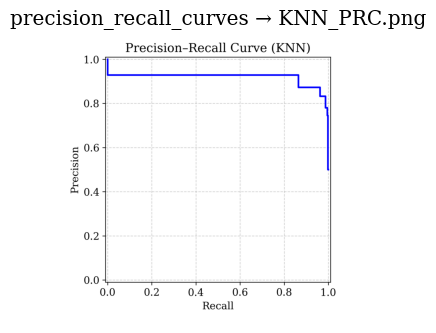

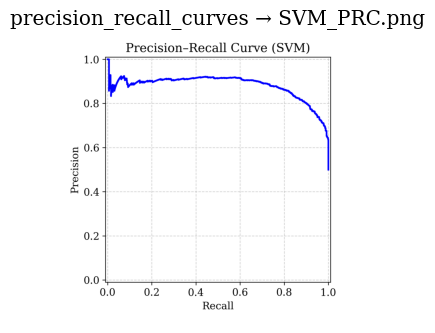

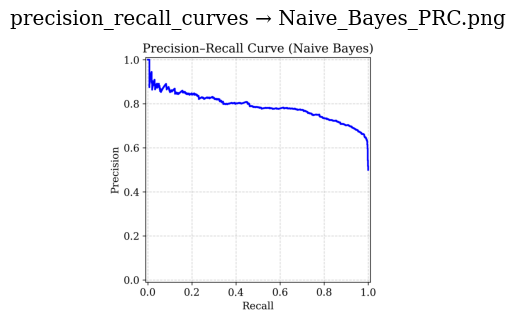

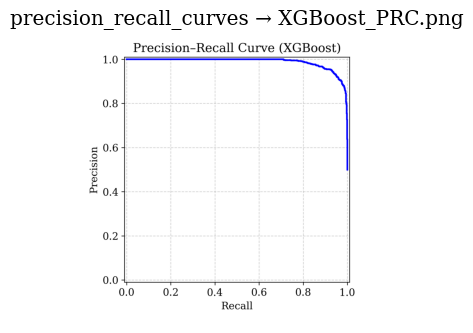

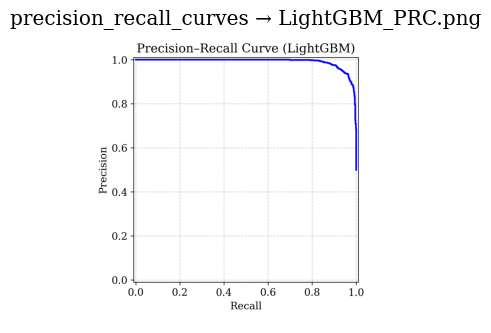


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/roc_curves


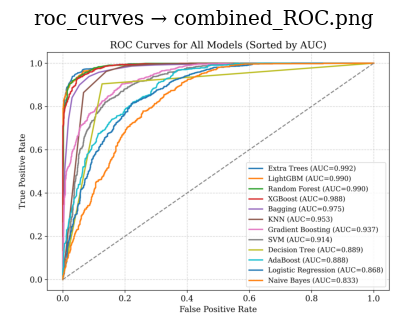

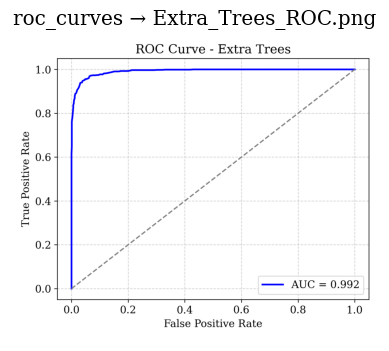

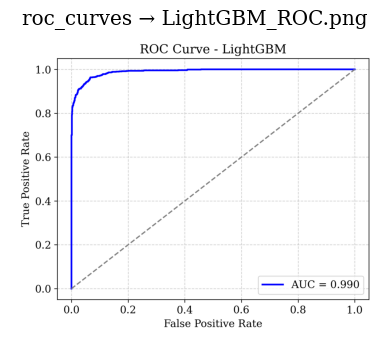

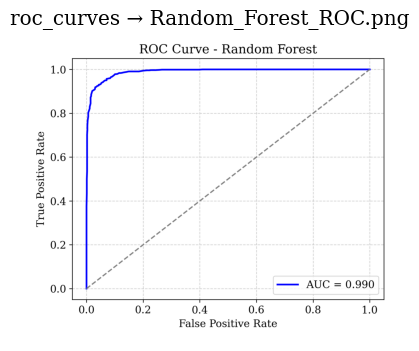

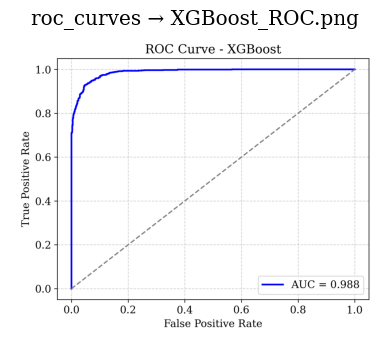

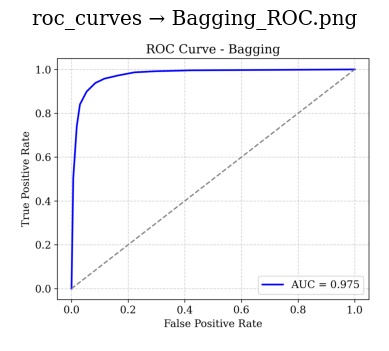

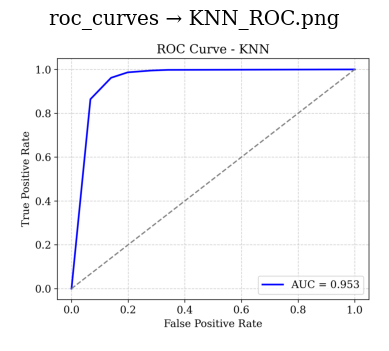

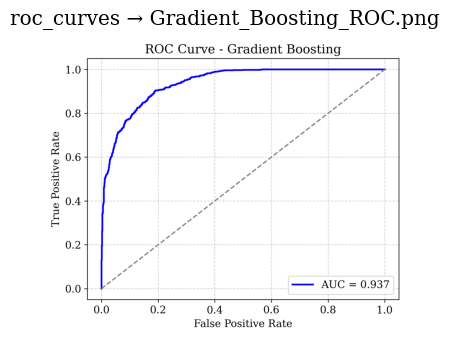

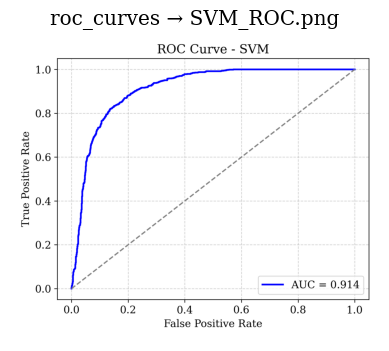

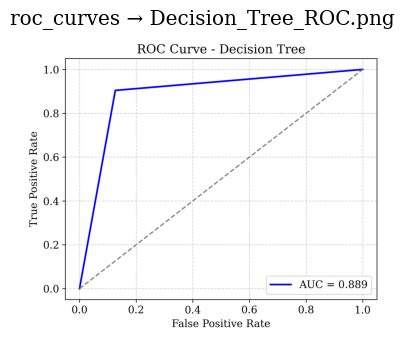

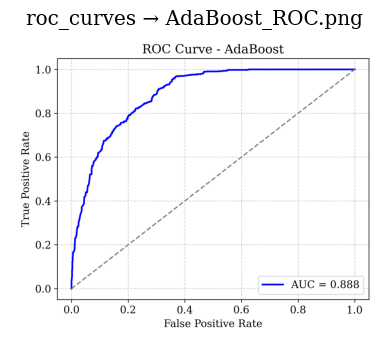

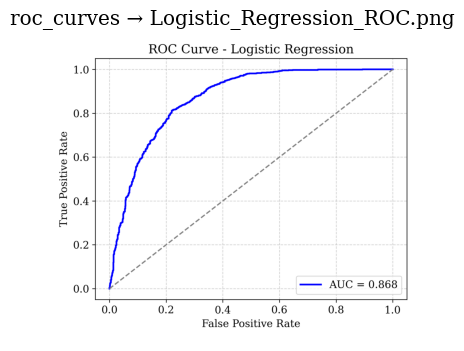

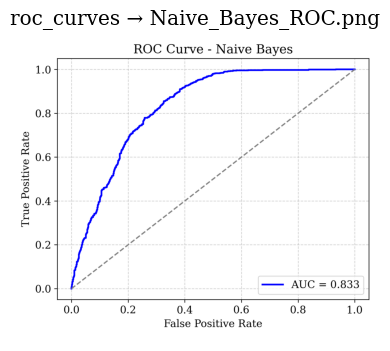

In [36]:
# ✅ Step 1: Import libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

# ✅ Step 2: Define all folders you want to display images from
folders = [
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/confusion_matrices',
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/precision_recall_curves',
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/roc_curves'

]

# ✅ Step 3: Loop through each folder and show its images
for folder in folders:
    print(f"\n📁 Showing images from folder: {folder}")

    # List all PNG images
    image_files = [f for f in os.listdir(folder) if f.endswith('.png')]

    for file in image_files:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)

        # Display image
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{os.path.basename(folder)} → {file}")
        plt.show()


## **With 5 folds cross validation**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, fbeta_score, brier_score_loss, log_loss,
    classification_report, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =====================================================
# 0️⃣ Create Timestamped Results Folder Structure
# =====================================================
base_path = "/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result"
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
main_path = os.path.join(base_path, f"with_cross_validation_{timestamp}")
os.makedirs(main_path, exist_ok=True)

folders = {
    "csv": os.path.join(main_path, "csv_metrics"),
    "roc": os.path.join(main_path, "roc_curves"),
    "confusion": os.path.join(main_path, "confusion_matrices"),
    "prc": os.path.join(main_path, "precision_recall_curves"),
    "training": os.path.join(main_path, "training_testing_curves"),
    "reports": os.path.join(main_path, "classification_reports"),
}
for p in folders.values():
    os.makedirs(p, exist_ok=True)

print(f"📁 All results will be saved in:\n{main_path}\n")

# =====================================================
# 1️⃣ Define All Models
# =====================================================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# =====================================================
# 2️⃣ 5-Fold Stratified Cross-Validation
# =====================================================
print("\n🔄 Running 5-Fold Stratified Cross-Validation...\n")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_results = []
roc_curves = []

for name, model in models.items():
    print(f"\n🚀 Evaluating Model: {name}")
    fold_metrics = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Probabilities for ROC/AUC
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
        except Exception:
            y_prob = model.decision_function(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        sensitivity = tp / (tp + fn)

        fold_metrics.append({
            "Model": name,
            "Fold": fold,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
            "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
            "Specificity": specificity,
            "Sensitivity": sensitivity,
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "Cohen Kappa": cohen_kappa_score(y_test, y_pred),
            "F2-Score": fbeta_score(y_test, y_pred, beta=2, average='weighted', zero_division=0),
            "Brier Score": brier_score_loss(y_test, y_prob),
            "Log Loss": log_loss(y_test, y_prob),
            "Samples": len(y_test)
        })

        # Store ROC of first fold for plotting
        if fold == 1:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_curves.append((name, fpr, tpr, roc_auc_score(y_test, y_prob)))

    df_folds = pd.DataFrame(fold_metrics)
    weights = df_folds["Samples"] / df_folds["Samples"].sum()
    weighted_avg = (df_folds.drop(columns=["Model", "Fold", "Samples"]).T @ weights).to_dict()
    weighted_avg["Model"] = name
    weighted_avg["Fold"] = "Weighted Avg"
    weighted_avg["Samples"] = df_folds["Samples"].sum()
    weighted_std = df_folds.drop(columns=["Model", "Fold", "Samples"]).std().to_dict()
    weighted_std["Model"], weighted_std["Fold"] = name, "±Std"

    df_folds = pd.concat([df_folds,
                          pd.DataFrame([weighted_avg]),
                          pd.DataFrame([weighted_std])], ignore_index=True)
    all_results.append(df_folds)

results_df = pd.concat(all_results, ignore_index=True)

# =====================================================
# 3️⃣ Save Metrics (CSV)
# =====================================================
csv_path = os.path.join(folders["csv"], "model_results_5fold_weighted.csv")
results_df.to_csv(csv_path, index=False)
print(f"✅ Metrics CSV saved: {csv_path}")

# =====================================================
# 4️⃣ Combined ROC Curves
# =====================================================
plt.figure(figsize=(8, 6))
for name, fpr, tpr, auc in roc_curves:
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Models (Representative Fold)")
plt.legend(fontsize='small', loc='lower right')
plt.grid(alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(folders["roc"], "combined_ROC.png"), dpi=300)
plt.close()
print("✅ ROC curves saved.\n")

# =====================================================
# 5️⃣ Confusion Matrices (Full-Data Refit)
# =====================================================
for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Greens", colorbar=True)
    plt.title(f"{name} – Confusion Matrix (Full Data)")
    plt.tight_layout()
    plt.savefig(os.path.join(folders["confusion"], f"{name.replace(' ', '_')}_confusion_matrix.png"), dpi=300)
    plt.close()
print("✅ Confusion matrices saved.\n")

# =====================================================
# 6️⃣ Precision–Recall Curves (Full-Data Refit)
# =====================================================
for name, model in models.items():
    model.fit(X, y)
    try:
        y_prob = model.predict_proba(X)[:, 1]
    except Exception:
        y_prob = model.decision_function(X)
    precision, recall, _ = precision_recall_curve(y, y_prob)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot(color='blue', lw=2)
    plt.title(f"Precision–Recall Curve ({name})")
    plt.grid(alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(folders["prc"], f"{name.replace(' ', '_')}_PRC.png"), dpi=300)
    plt.close()
print("✅ Precision–Recall curves saved.\n")

# =====================================================
# 7️⃣ Training vs Testing Curves
# =====================================================
n_estimators_range = np.arange(1, 110, 10)
print("📈 Generating Training vs Testing Curves...\n")
for name, model in models.items():
    if hasattr(model, "n_estimators"):
        train_acc, test_acc = [], []
        for n in n_estimators_range:
            model.set_params(n_estimators=n)
            model.fit(X_train, y_train)
            train_acc.append(model.score(X_train, y_train))
            test_acc.append(model.score(X_test, y_test))
        plt.figure(figsize=(7,5))
        plt.plot(n_estimators_range, train_acc, 'ro-', label='Training Accuracy')
        plt.plot(n_estimators_range, test_acc, 'go-', label='Testing Accuracy')
        plt.title(f'Accuracy vs Number of Estimators ({name})')
        plt.xlabel('Number of Estimators (Trees)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(folders["training"], f"{name.replace(' ', '_')}_training_curve.png"), dpi=300)
        plt.close()
print("✅ All Training vs Testing Curves saved.\n")

# =====================================================
# 8️⃣ Best Model Identification & Report
# =====================================================
weighted_results = results_df[results_df["Fold"] == "Weighted Avg"]
best_model_name = weighted_results.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X, y)
final_report = classification_report(y, best_model.predict(X), digits=5)

report_path = os.path.join(folders["reports"], f"{best_model_name.replace(' ', '_')}_report.txt")
with open(report_path, "w") as f:
    f.write(f"Best Model: {best_model_name}\n\n{final_report}")
print(f"🏆 Best Model: {best_model_name}")
print(final_report)
print(f"✅ Report saved: {report_path}")

# =====================================================
# 9️⃣ Summary
# =====================================================
print("\n🎯 All results generated successfully!")
for k, v in folders.items():
    print(f"📂 {k.capitalize()}: {v}")


📁 All results will be saved in:
/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/with_cross_validation_2025-10-14_09-50-57


🔄 Running 5-Fold Stratified Cross-Validation...


🚀 Evaluating Model: Decision Tree

🚀 Evaluating Model: Random Forest

🚀 Evaluating Model: Extra Trees

🚀 Evaluating Model: Gradient Boosting

🚀 Evaluating Model: AdaBoost

🚀 Evaluating Model: Bagging

🚀 Evaluating Model: Logistic Regression

🚀 Evaluating Model: KNN

🚀 Evaluating Model: SVM

🚀 Evaluating Model: Naive Bayes

🚀 Evaluating Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:34] WARNING: /w


🚀 Evaluating Model: LightGBM
[LightGBM] [Info] Number of positive: 199, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 888
[LightGBM] [Info] Number of data points in the train set: 4088, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048679 -> initscore=-2.972603
[LightGBM] [Info] Start training from score -2.972603
[LightGBM] [Info] Number of positive: 199, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000789 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 888
[LightGBM] [Info] Number of data points in the train set: 4088, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048679 -> initscore=-2.972603
[LightGBM] [Info] Start training from score -2

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 249, number of negative: 4861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 890
[LightGBM] [Info] Number of data points in the train set: 5110, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048728 -> initscore=-2.971547
[LightGBM] [Info] Start training from score -2.971547
✅ Confusion matrices saved.



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 249, number of negative: 4861
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 890
[LightGBM] [Info] Number of data points in the train set: 5110, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048728 -> initscore=-2.971547
[LightGBM] [Info] Start training from score -2.971547
✅ Precision–Recall curves saved.

📈 Generating Training vs Testing Curves...



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:52:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:52:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:52:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:52:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:52:28] WARNING: /w

[LightGBM] [Info] Number of positive: 200, number of negative: 3888
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 887
[LightGBM] [Info] Number of data points in the train set: 4088, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048924 -> initscore=-2.967333
[LightGBM] [Info] Start training from score -2.967333
[LightGBM] [Info] Number of positive: 200, number of negative: 3888
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 887
[LightGBM] [Info] Number of data points in the train set: 4088, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048924 -> initscore=-2.967333
[LightGBM] [Info] Start training from score -2.967333
[LightGBM] [Info] Numb

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/5th_folds_with_cross_validation_2025-10-14_09-50-57/confusion_matrices


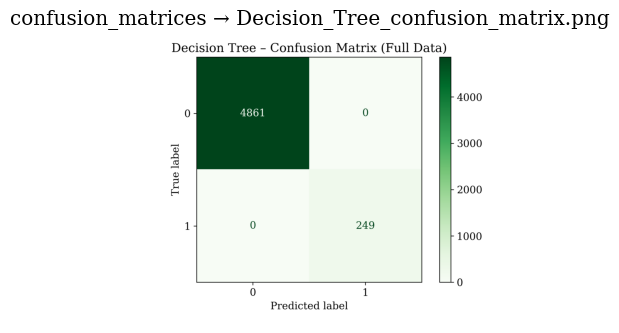

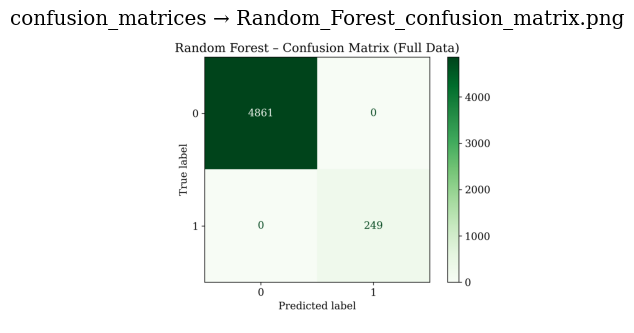

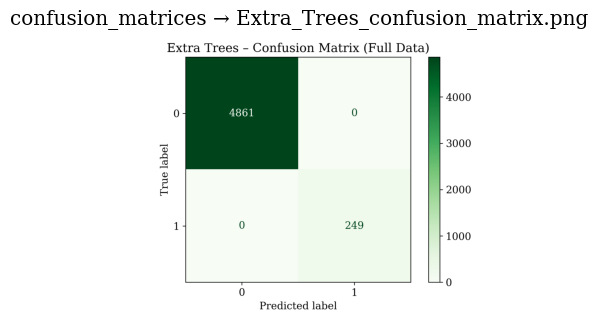

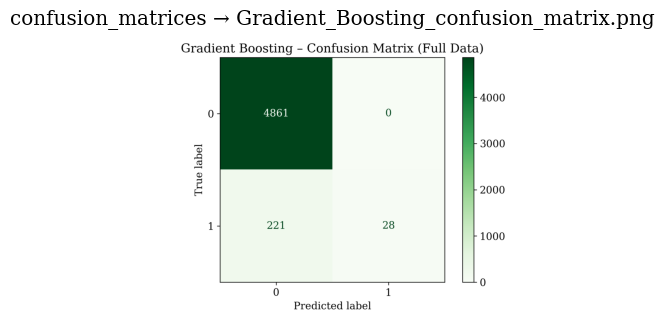

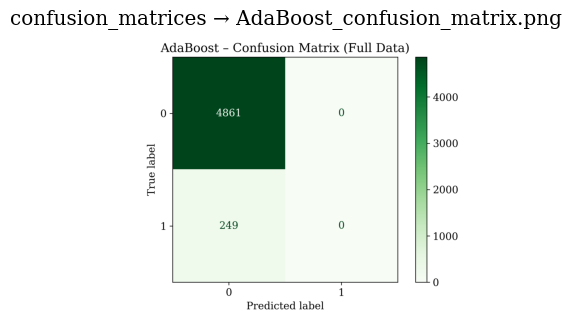

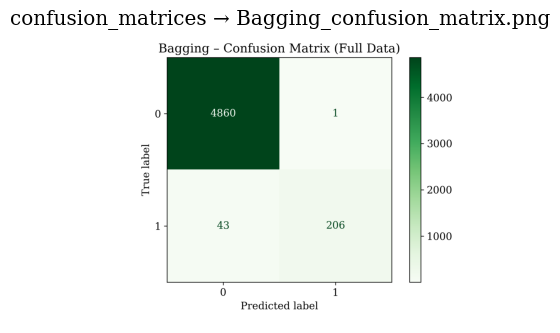

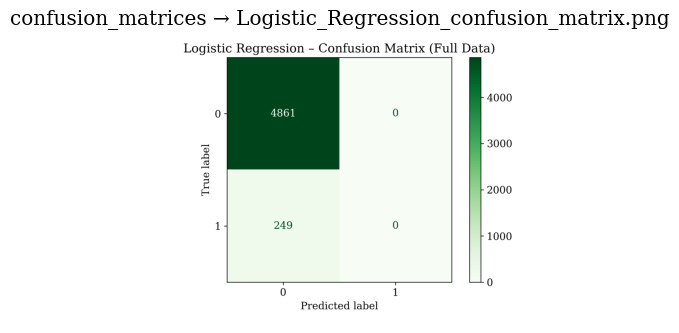

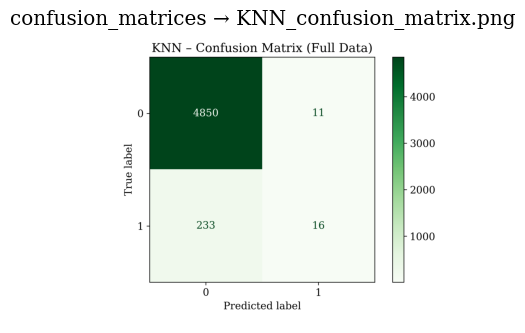

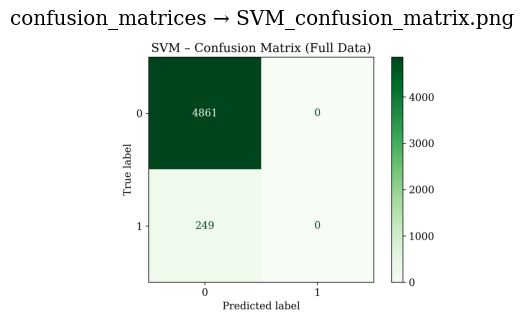

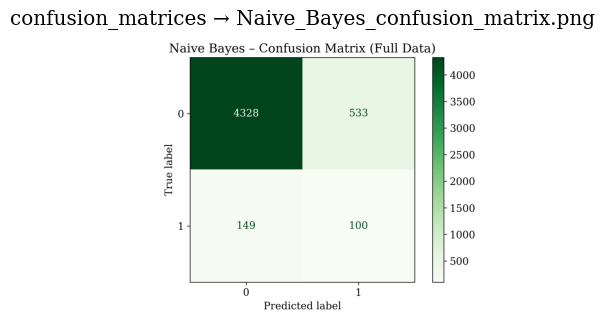

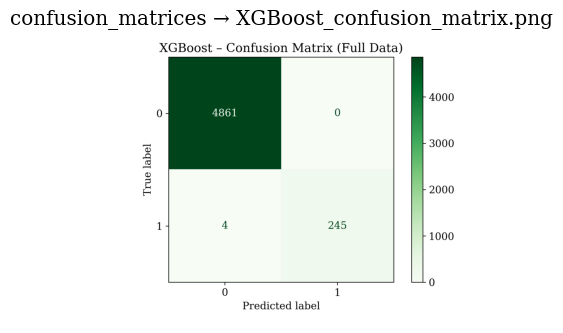

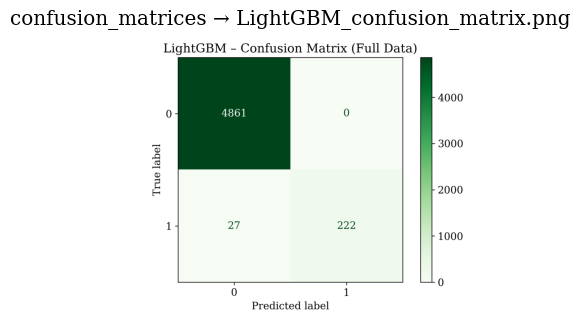


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/5th_folds_with_cross_validation_2025-10-14_09-50-57/precision_recall_curves


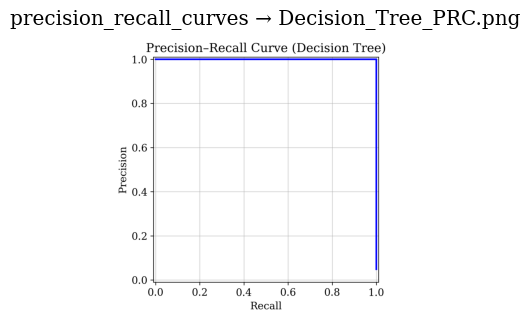

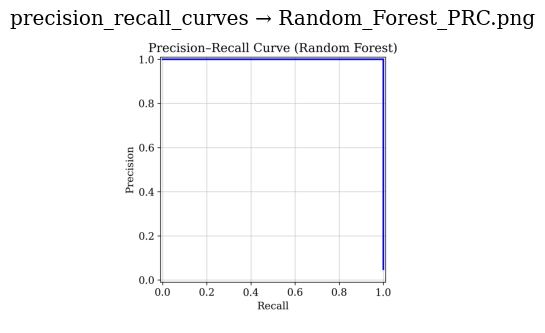

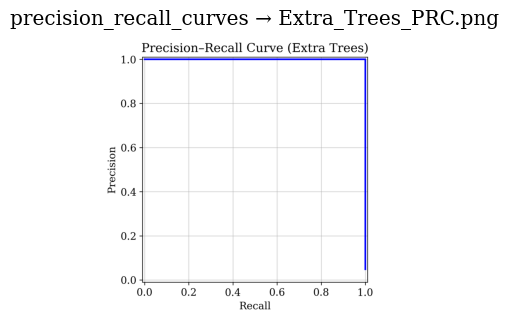

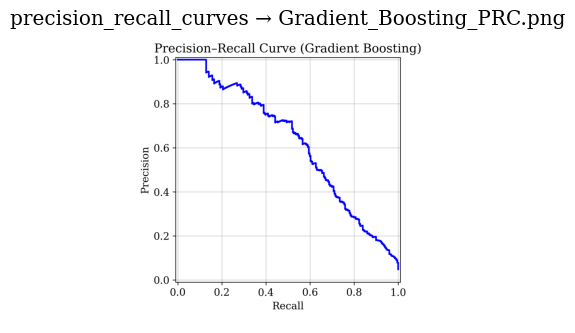

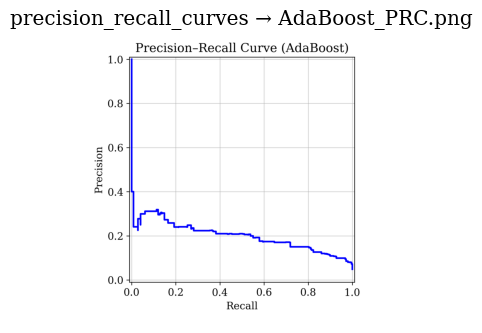

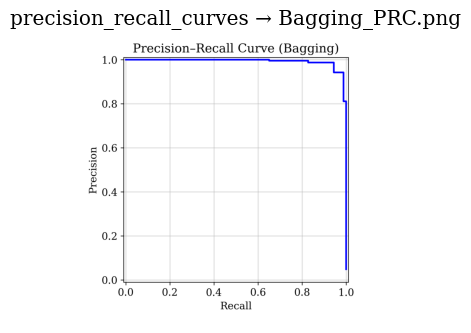

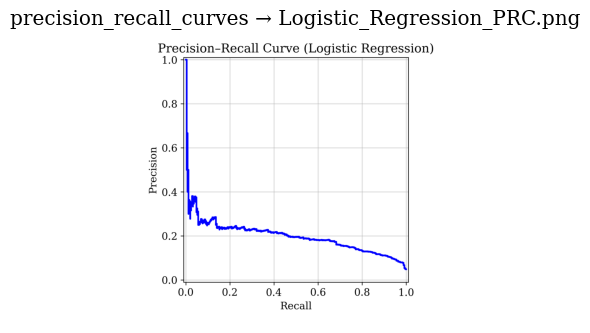

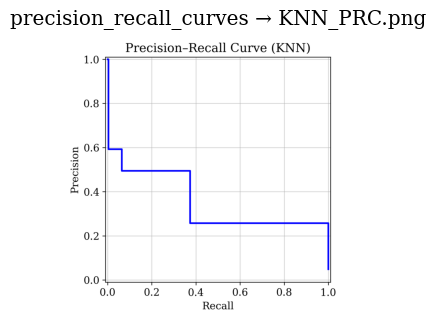

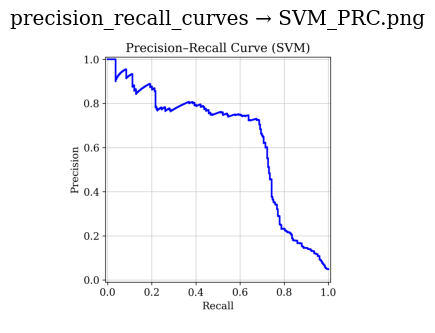

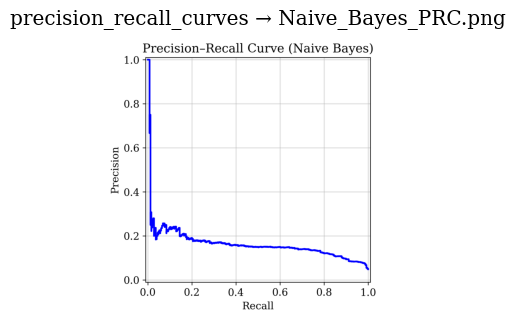

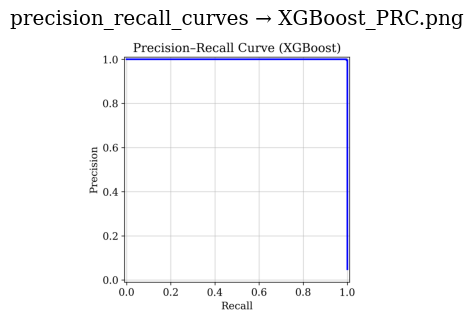

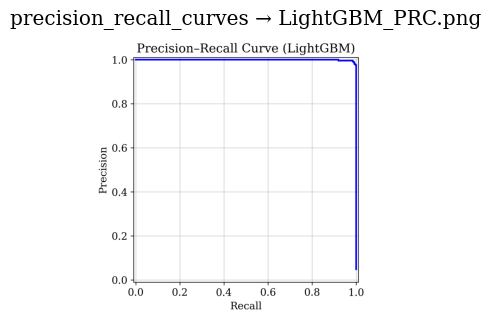


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/5th_folds_with_cross_validation_2025-10-14_09-50-57/roc_curves


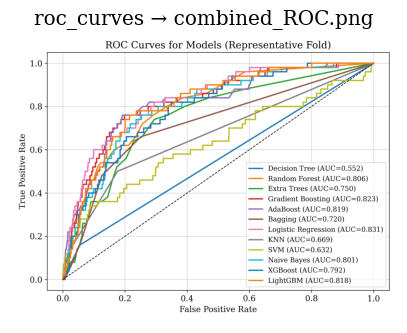

In [37]:
# ✅ Step 1: Import libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

# ✅ Step 2: Define all folders you want to display images from
folders = [
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/5th_folds_with_cross_validation_2025-10-14_09-50-57/confusion_matrices',
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/5th_folds_with_cross_validation_2025-10-14_09-50-57/precision_recall_curves',
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/5th_folds_with_cross_validation_2025-10-14_09-50-57/roc_curves'

]

# ✅ Step 3: Loop through each folder and show its images
for folder in folders:
    print(f"\n📁 Showing images from folder: {folder}")

    # List all PNG images
    image_files = [f for f in os.listdir(folder) if f.endswith('.png')]

    for file in image_files:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)

        # Display image
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{os.path.basename(folder)} → {file}")
        plt.show()


In [25]:
# Access the file in Google Drive
result2 = pd.read_csv("/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/with_cross_validation_2025-10-14_09-50-57/csv_metrics/model_results_5fold_weighted.csv")
print(result2)

            Model          Fold  Accuracy  Precision    Recall  F1-Score  \
0   Decision Tree             1  0.906067   0.915779  0.906067  0.910807   
1   Decision Tree             2  0.911937   0.913580  0.911937  0.912755   
2   Decision Tree             3  0.916830   0.920630  0.916830  0.918703   
3   Decision Tree             4  0.914873   0.917238  0.914873  0.916047   
4   Decision Tree             5  0.904110   0.915686  0.904110  0.909755   
..            ...           ...       ...        ...       ...       ...   
79       LightGBM             3  0.941292   0.904086  0.941292  0.922314   
80       LightGBM             4  0.945205   0.911232  0.945205  0.925945   
81       LightGBM             5  0.943249   0.911212  0.943249  0.925821   
82       LightGBM  Weighted Avg  0.945010   0.912630  0.945010  0.926345   
83       LightGBM          ±Std  0.002802   0.006900  0.002802  0.002987   

     ROC-AUC  Specificity  Sensitivity  Balanced Accuracy       MCC  \
0   0.552222    

## **With 10 folds Cross validation**

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, fbeta_score, brier_score_loss, log_loss,
    classification_report, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =====================================================
# 0️⃣ Folder setup
# =====================================================
base_path = "/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation"
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
main_path = os.path.join(base_path, f"with_cross_validation_{timestamp}")
os.makedirs(main_path, exist_ok=True)

folders = {k: os.path.join(main_path, v) for k, v in {
    "csv": "csv_metrics",
    "roc": "roc_curves",
    "confusion": "confusion_matrices",
    "prc": "precision_recall_curves",
    "training": "training_testing_curves",
    "reports": "classification_reports"
}.items()}
for p in folders.values():
    os.makedirs(p, exist_ok=True)

print(f"📁 Results directory:\n{main_path}\n")

# =====================================================
# 1️⃣ Define models
# =====================================================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# =====================================================
# 2️⃣ 10-Fold Stratified Cross-Validation
# =====================================================
print("\n🔄 Running 10-Fold Stratified Cross-Validation...\n")
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_results, roc_curves = [], []

for name, model in models.items():
    print(f"\n🚀 Evaluating Model: {name}")
    fold_metrics = []
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Probabilities
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
        except Exception:
            y_prob = model.decision_function(X_test)

        # Confusion metrics
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        sensitivity = tp / (tp + fn)

        # Store metrics
        fold_metrics.append({
            "Model": name,
            "Fold": fold,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
            "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
            "Specificity": specificity,
            "Sensitivity": sensitivity,
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "Cohen Kappa": cohen_kappa_score(y_test, y_pred),
            "F2-Score": fbeta_score(y_test, y_pred, beta=2, average='weighted', zero_division=0),
            "Brier Score": brier_score_loss(y_test, y_prob),
            "Log Loss": log_loss(y_test, y_prob),
            "Samples": len(y_test)
        })

        # ROC curve aggregation
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(y_test, y_prob))

    # --- Weighted average + std ---
    df_folds = pd.DataFrame(fold_metrics)
    weights = df_folds["Samples"] / df_folds["Samples"].sum()
    weighted_avg = (df_folds.drop(columns=["Model", "Fold", "Samples"]).T @ weights).to_dict()
    weighted_avg["Model"], weighted_avg["Fold"], weighted_avg["Samples"] = name, "Weighted Avg", df_folds["Samples"].sum()
    weighted_std = df_folds.drop(columns=["Model", "Fold", "Samples"]).std().to_dict()
    weighted_std["Model"], weighted_std["Fold"] = name, "±Std"
    df_folds = pd.concat([df_folds, pd.DataFrame([weighted_avg]), pd.DataFrame([weighted_std])], ignore_index=True)
    all_results.append(df_folds)

    # --- Mean ROC curve with ±1σ ---
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    std_tpr = np.std(tprs, axis=0)
    mean_tpr[-1] = 1.0
    roc_curves.append((name, mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc))

results_df = pd.concat(all_results, ignore_index=True)

# =====================================================
# 3️⃣ Save metrics
# =====================================================
csv_path = os.path.join(folders["csv"], "model_results_10fold_weighted.csv")
results_df.to_csv(csv_path, index=False)
print(f"✅ Metrics CSV saved: {csv_path}")

# =====================================================
# 4️⃣ Mean ± Std ROC curves (publication-quality)
# =====================================================
plt.figure(figsize=(8, 6))
for name, mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc in roc_curves:
    plt.plot(mean_fpr, mean_tpr, lw=2,
             label=f'{name} (AUC={mean_auc:.3f} ± {std_auc:.3f})')
    plt.fill_between(mean_fpr,
                     np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1),
                     alpha=0.15)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curves (10-Fold CV, Mean ± 1σ)")
plt.legend(fontsize='small', loc='lower right')
plt.grid(alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(folders["roc"], "mean_std_ROC_10fold.png"), dpi=300)
plt.close()
print("✅ Mean ± Std ROC curves saved.\n")

# =====================================================
# 5️⃣ Confusion Matrices (Full-Data Refit)
# =====================================================
for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Greens", colorbar=True)
    plt.title(f"{name} – Confusion Matrix (Full Data)")
    plt.tight_layout()
    plt.savefig(os.path.join(folders["confusion"], f"{name.replace(' ', '_')}_confusion_matrix.png"), dpi=300)
    plt.close()
print("✅ Confusion matrices saved.\n")

# =====================================================
# 6️⃣ Precision–Recall Curves (Full-Data)
# =====================================================
for name, model in models.items():
    model.fit(X, y)
    try:
        y_prob = model.predict_proba(X)[:, 1]
    except Exception:
        y_prob = model.decision_function(X)
    precision, recall, _ = precision_recall_curve(y, y_prob)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot(color='blue', lw=2)
    plt.title(f"Precision–Recall Curve ({name})")
    plt.grid(alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(folders["prc"], f"{name.replace(' ', '_')}_PRC.png"), dpi=300)
    plt.close()
print("✅ Precision–Recall curves saved.\n")

# =====================================================
# 7️⃣ Training vs Testing Curves
# =====================================================
n_estimators_range = np.arange(1, 110, 10)
print("📈 Generating Training vs Testing Curves...\n")
for name, model in models.items():
    if hasattr(model, "n_estimators"):
        train_acc, test_acc = [], []
        for n in n_estimators_range:
            model.set_params(n_estimators=n)
            model.fit(X_train, y_train)
            train_acc.append(model.score(X_train, y_train))
            test_acc.append(model.score(X_test, y_test))
        plt.figure(figsize=(7,5))
        plt.plot(n_estimators_range, train_acc, 'ro-', label='Training Accuracy')
        plt.plot(n_estimators_range, test_acc, 'go-', label='Testing Accuracy')
        plt.title(f'Accuracy vs Estimators ({name})')
        plt.xlabel('Number of Estimators')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(folders["training"], f"{name.replace(' ', '_')}_training_curve.png"), dpi=300)
        plt.close()
print("✅ Training vs Testing Curves saved.\n")

# =====================================================
# 8️⃣ Best Model & Report
# =====================================================
weighted_results = results_df[results_df["Fold"] == "Weighted Avg"]
best_model_name = weighted_results.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X, y)
final_report = classification_report(y, best_model.predict(X), digits=5)

report_path = os.path.join(folders["reports"], f"{best_model_name.replace(' ', '_')}_report.txt")
with open(report_path, "w") as f:
    f.write(f"Best Model: {best_model_name}\n\n{final_report}")
print(f"🏆 Best Model: {best_model_name}")
print(final_report)
print(f"✅ Report saved: {report_path}")

# =====================================================
# 9️⃣ Summary
# =====================================================
print("\n🎯 All results generated successfully!")
for k, v in folders.items():
    print(f"📂 {k.capitalize()}: {v}")


📁 Results directory:
/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35


🔄 Running 10-Fold Stratified Cross-Validation...


🚀 Evaluating Model: Decision Tree

🚀 Evaluating Model: Random Forest

🚀 Evaluating Model: Extra Trees

🚀 Evaluating Model: Gradient Boosting

🚀 Evaluating Model: AdaBoost

🚀 Evaluating Model: Bagging

🚀 Evaluating Model: Logistic Regression

🚀 Evaluating Model: KNN

🚀 Evaluating Model: SVM

🚀 Evaluating Model: Naive Bayes

🚀 Evaluating Model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:32] WARNING: /w


🚀 Evaluating Model: LightGBM
[LightGBM] [Info] Number of positive: 224, number of negative: 4375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 4599, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048706 -> initscore=-2.972016
[LightGBM] [Info] Start training from score -2.972016
[LightGBM] [Info] Number of positive: 224, number of negative: 4375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 4599, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048706 -> initscore=-2.972016
[LightGBM] [Info] Start training from score -2

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 249, number of negative: 4861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 890
[LightGBM] [Info] Number of data points in the train set: 5110, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048728 -> initscore=-2.971547
[LightGBM] [Info] Start training from score -2.971547
✅ Confusion matrices saved.



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:12:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 249, number of negative: 4861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 890
[LightGBM] [Info] Number of data points in the train set: 5110, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048728 -> initscore=-2.971547
[LightGBM] [Info] Start training from score -2.971547
✅ Precision–Recall curves saved.

📈 Generating Training vs Testing Curves...



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:13:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:13:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:13:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:13:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:13:30] WARNING: /w

[LightGBM] [Info] Number of positive: 225, number of negative: 4374
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 890
[LightGBM] [Info] Number of data points in the train set: 4599, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048924 -> initscore=-2.967333
[LightGBM] [Info] Start training from score -2.967333
[LightGBM] [Info] Number of positive: 225, number of negative: 4374
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 890
[LightGBM] [Info] Number of data points in the train set: 4599, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048924 -> initscore=-2.967333
[LightGBM] [Info] Start training from score -2.967333
[LightGBM] [Info] Numb

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
# Access the file in Google Drive
result3 = pd.read_csv("/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/csv_metrics/model_results_10fold_weighted.csv")
print(result3)

             Model          Fold  Accuracy  Precision    Recall  F1-Score  \
0    Decision Tree             1  0.919765   0.924147  0.919765  0.921912   
1    Decision Tree             2  0.919765   0.911417  0.919765  0.915513   
2    Decision Tree             3  0.890411   0.910900  0.890411  0.900331   
3    Decision Tree             4  0.900196   0.908860  0.900196  0.904474   
4    Decision Tree             5  0.917808   0.926458  0.917808  0.921956   
..             ...           ...       ...        ...       ...       ...   
139       LightGBM             8  0.949119   0.922451  0.949119  0.929694   
140       LightGBM             9  0.939335   0.903993  0.939335  0.921325   
141       LightGBM            10  0.943249   0.916251  0.943249  0.928174   
142       LightGBM  Weighted Avg  0.945988   0.911003  0.945988  0.926483   
143       LightGBM          ±Std  0.003087   0.009147  0.003087  0.003309   

      ROC-AUC  Specificity  Sensitivity  Balanced Accuracy       MCC  \
0  


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/confusion_matrices


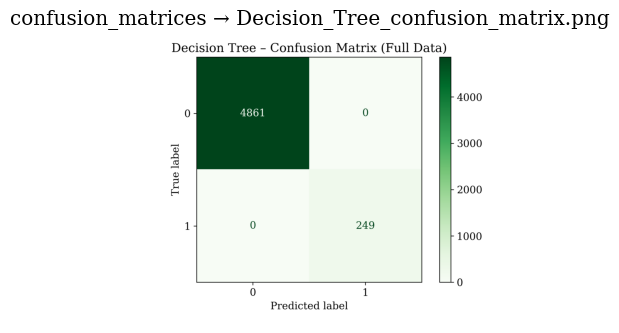

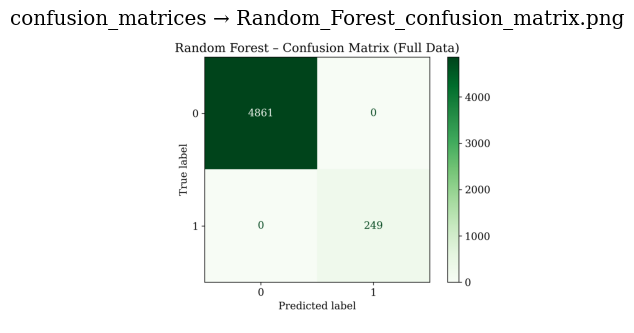

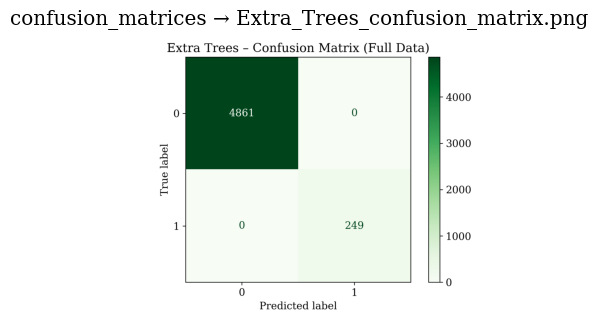

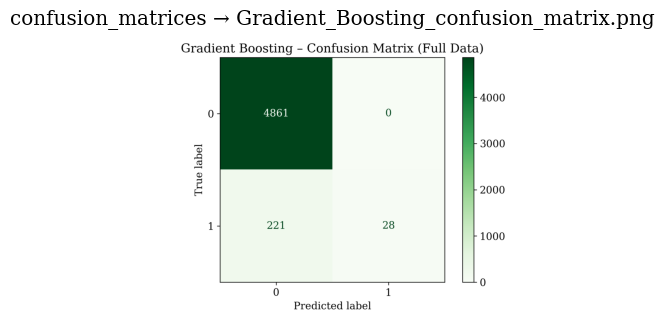

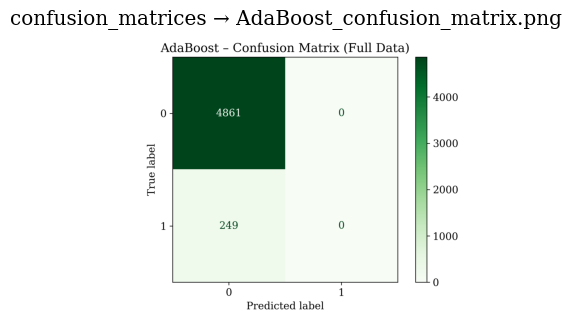

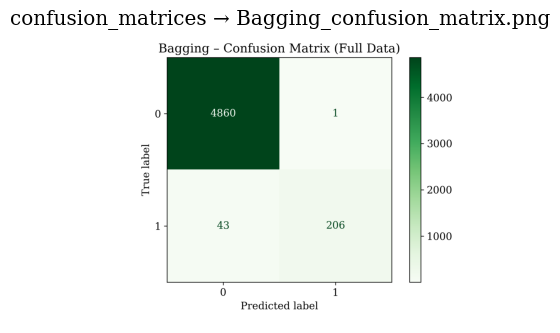

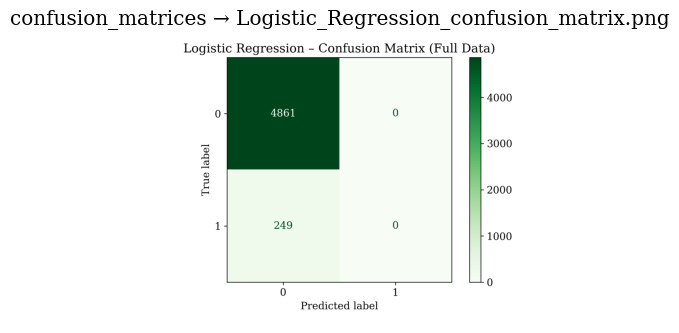

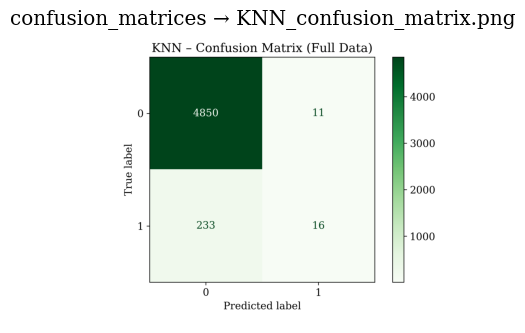

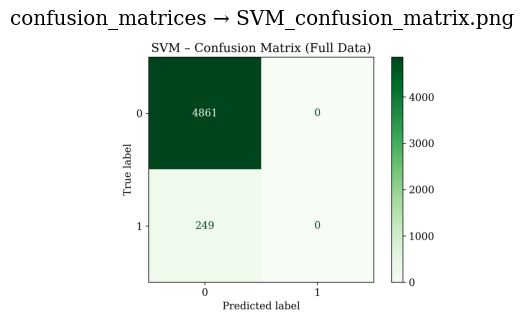

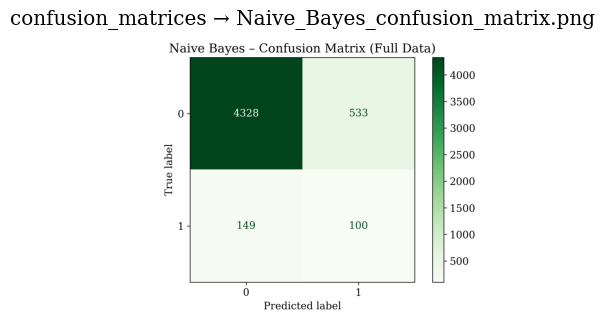

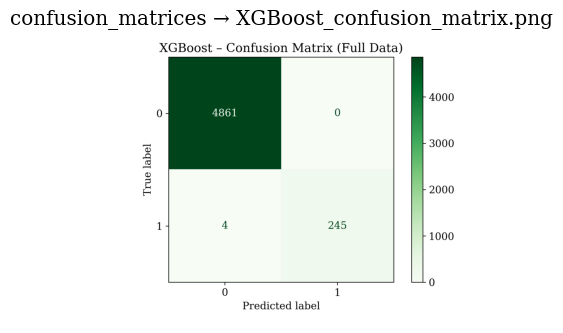

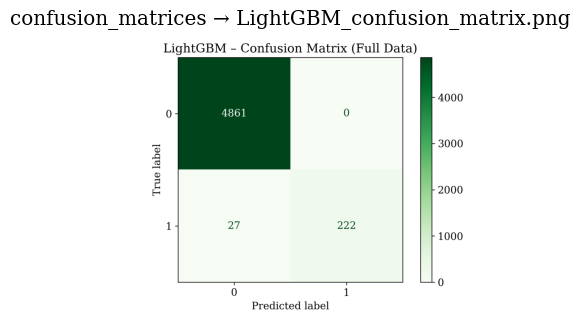


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/precision_recall_curves


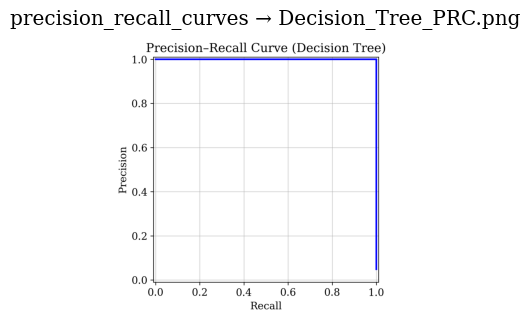

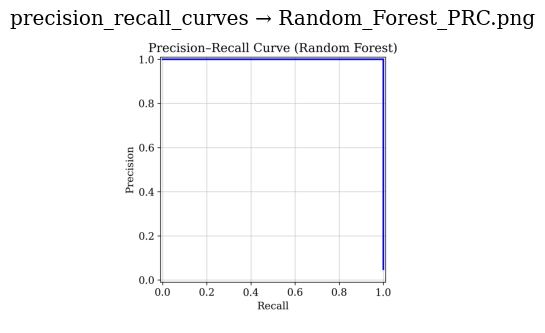

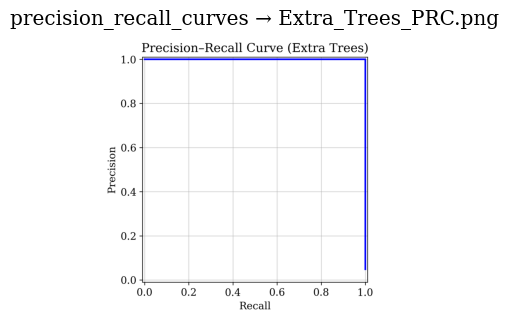

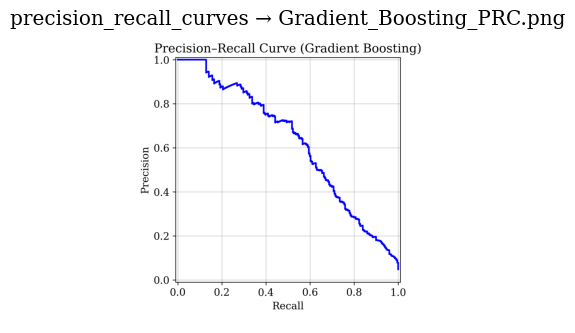

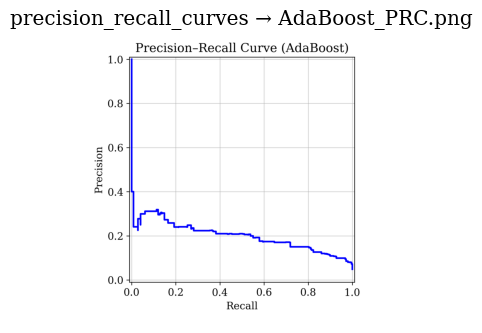

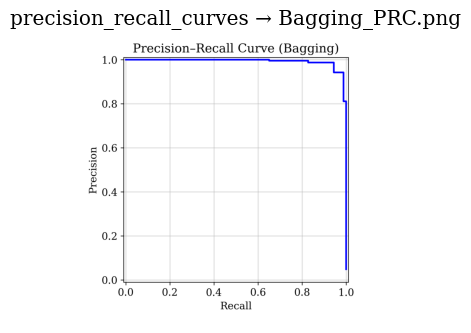

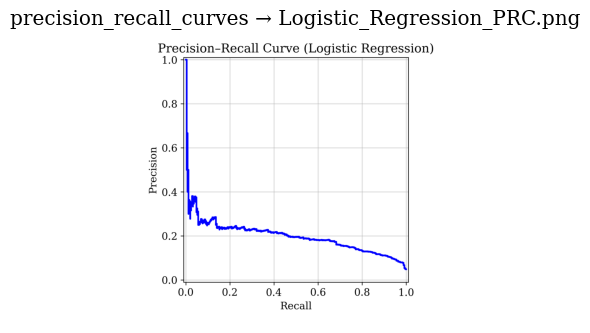

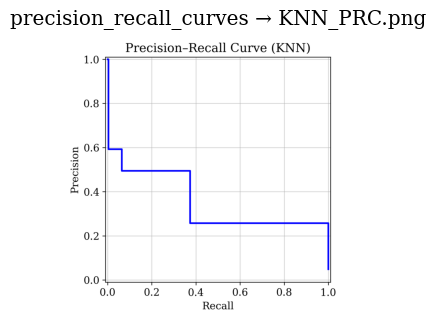

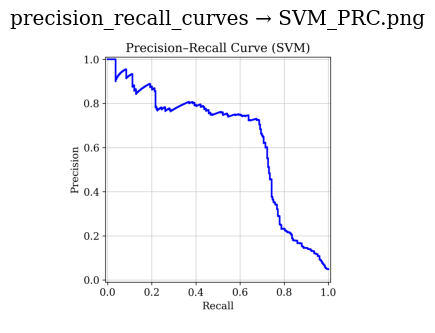

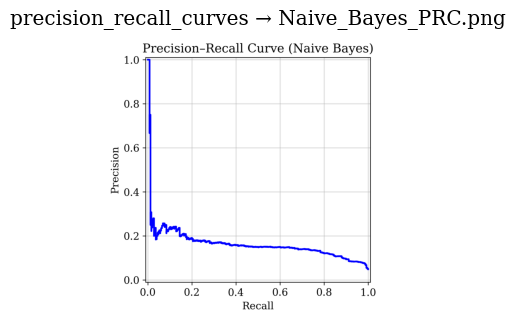

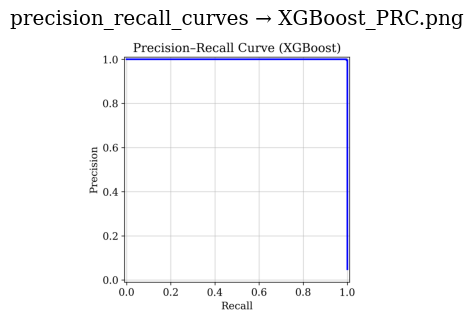

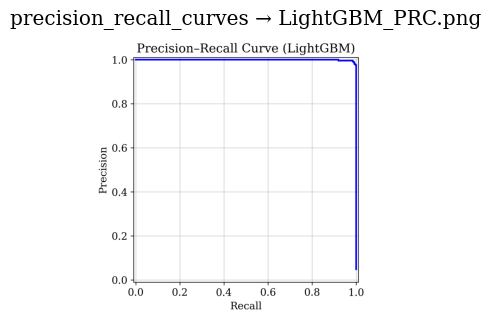


📁 Showing images from folder: /content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/roc_curves


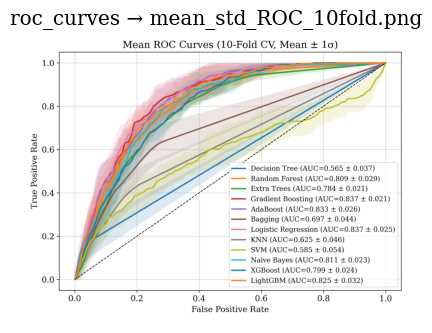

In [38]:
# ✅ Step 1: Import libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

# ✅ Step 2: Define all folders you want to display images from
folders = [
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/confusion_matrices',
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/precision_recall_curves',
    '/content/drive/MyDrive/skill_morph/Results_14_10_2025/results_2025-10-14_09-43-42/Cross_Validation_Result/10th_folds_cross_validation/with_cross_validation_2025-10-14_10-11-35/roc_curves'

]

# ✅ Step 3: Loop through each folder and show its images
for folder in folders:
    print(f"\n📁 Showing images from folder: {folder}")

    # List all PNG images
    image_files = [f for f in os.listdir(folder) if f.endswith('.png')]

    for file in image_files:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)

        # Display image
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{os.path.basename(folder)} → {file}")
        plt.show()
